In [2]:
from pathlib import Path
import polars as pl
import numpy as np

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-07-09/"
df_scenarios = pl.read_json(root + "scenarios.json")
print(df_scenarios)

ls = np.unique(df_scenarios["l"].to_numpy())
print(ls)

shape: (20, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 5   ┆ 0     ┆ periodic │
│ 150 ┆ 10  ┆ 0     ┆ periodic │
│ 150 ┆ 15  ┆ 0     ┆ periodic │
│ 150 ┆ 20  ┆ 0     ┆ periodic │
│ 150 ┆ 25  ┆ 0     ┆ periodic │
│ …   ┆ …   ┆ …     ┆ …        │
│ 150 ┆ 150 ┆ 0     ┆ random   │
│ 150 ┆ 10  ┆ 5     ┆ random   │
│ 150 ┆ 10  ┆ 10    ┆ random   │
│ 150 ┆ 10  ┆ 15    ┆ random   │
│ 150 ┆ 10  ┆ 0     ┆ homogen  │
└─────┴─────┴───────┴──────────┘
[  5  10  15  20  25  50 100 150]


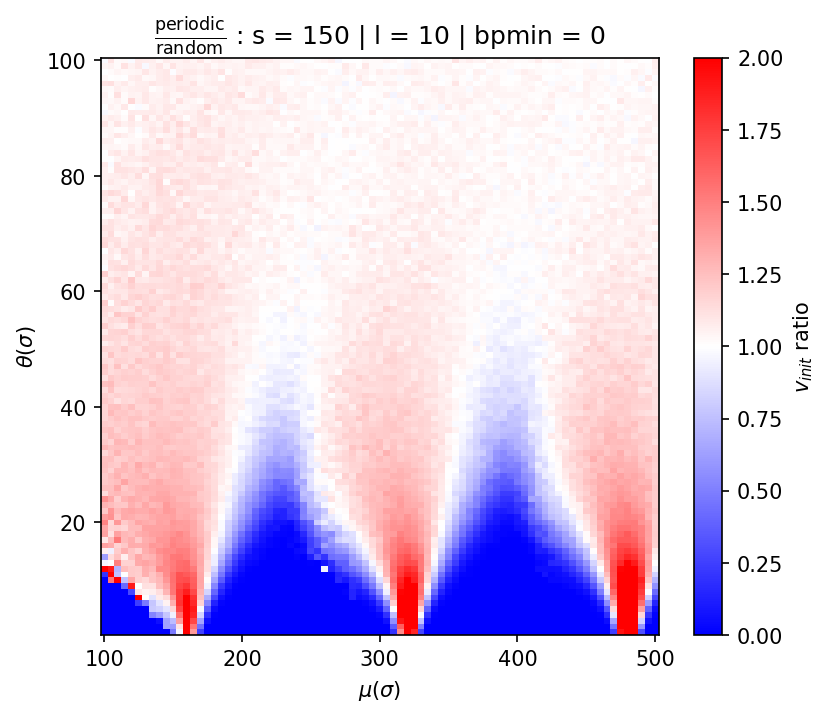

In [3]:
import matplotlib.pyplot as plt
from nucleo.io.plots_2D import find_config_idx, plot_one_heatmap_ratio_from_df


df = pl.read_parquet(root + "ncl_heatmaps.parquet")
s = 150
l = 10
bpmin = 0

idx_num = find_config_idx(df, s=s, l=l, bpmin=bpmin, land="periodic")
idx_den = find_config_idx(df, s=s, l=l, bpmin=bpmin, land="random")

ax, c = plot_one_heatmap_ratio_from_df(
    df,
    config_idx_num=idx_num,
    config_idx_den=idx_den,
    speed_col="vf",   # v_init
)

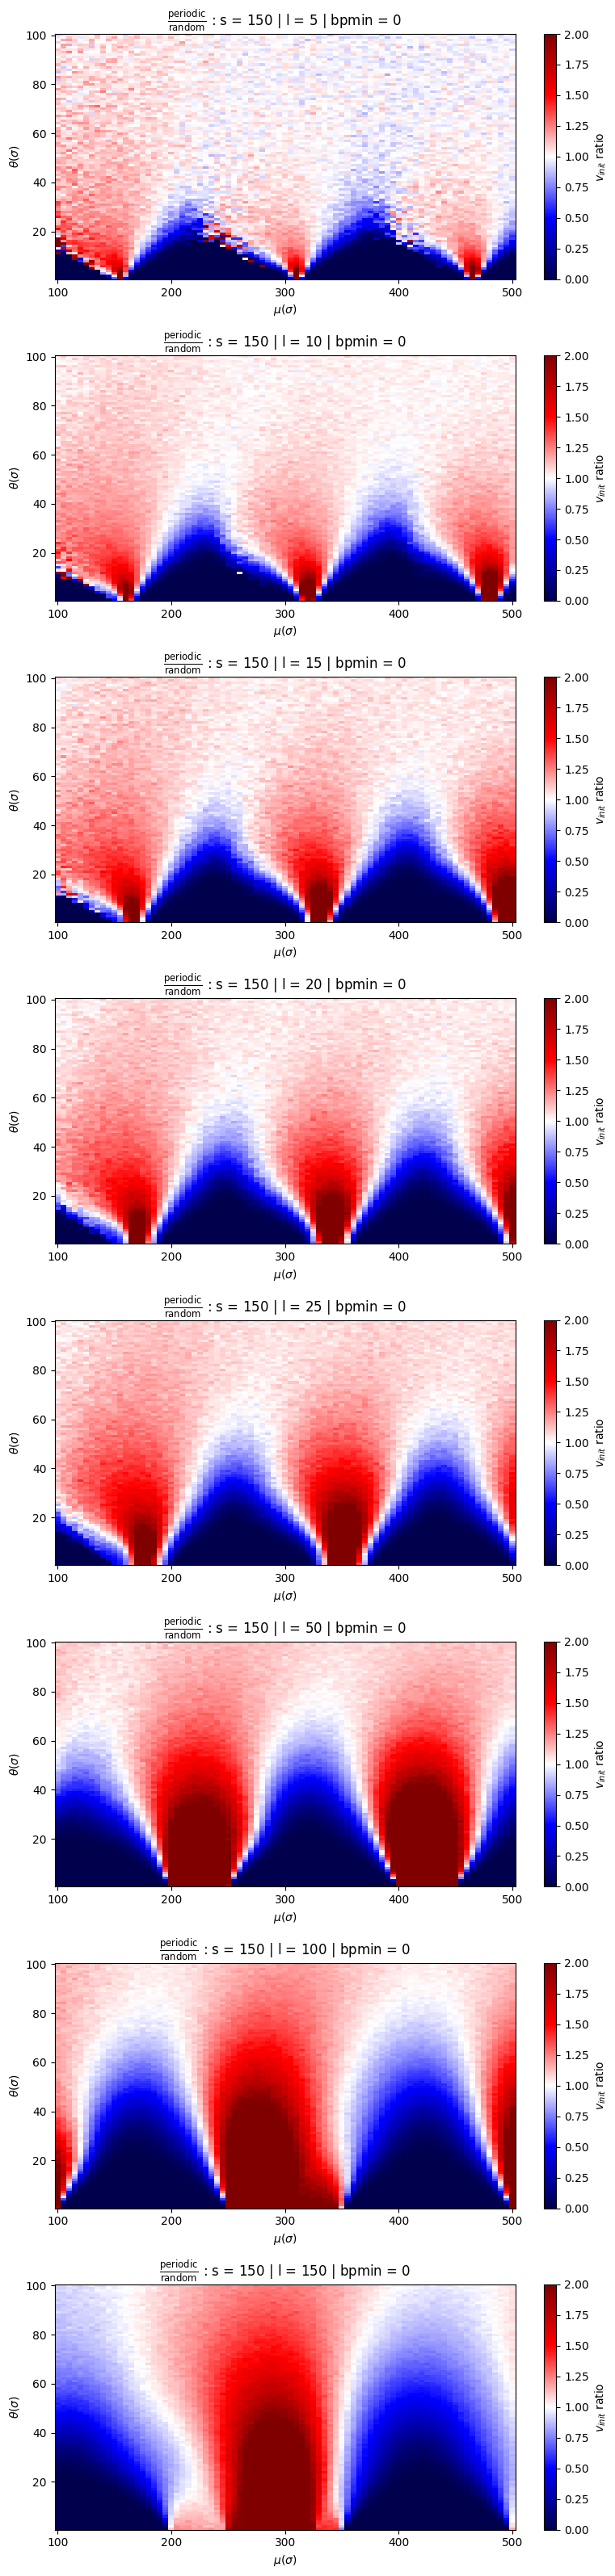

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from nucleo.io.plots_2D import (
    find_config_idx,
    plot_one_heatmap_ratio_from_df,
)

df = pl.read_parquet(root + "ncl_heatmaps.parquet")

S = 150
BPMIN = 0
LAND_NUM = "periodic"
LAND_DEN = "random"

fig, axes = plt.subplots(
    nrows=len(ls),
    figsize=(8, 4 * len(ls)),
    squeeze=False,
)

for ax, l in zip(axes.ravel(), ls):

    idx_num = find_config_idx(
        df,
        s=S,
        l=l,
        bpmin=BPMIN,
        land=LAND_NUM,
    )

    idx_den = find_config_idx(
        df,
        s=S,
        l=l,
        bpmin=BPMIN,
        land=LAND_DEN,
    )

    plot_one_heatmap_ratio_from_df(
        df,
        config_idx_num=idx_num,
        config_idx_den=idx_den,
        speed_col="vf",
        ax=ax,
        cmap="seismic",
    )

plt.tight_layout()
plt.savefig("supfig2_final.png", bbox_inches="tight")

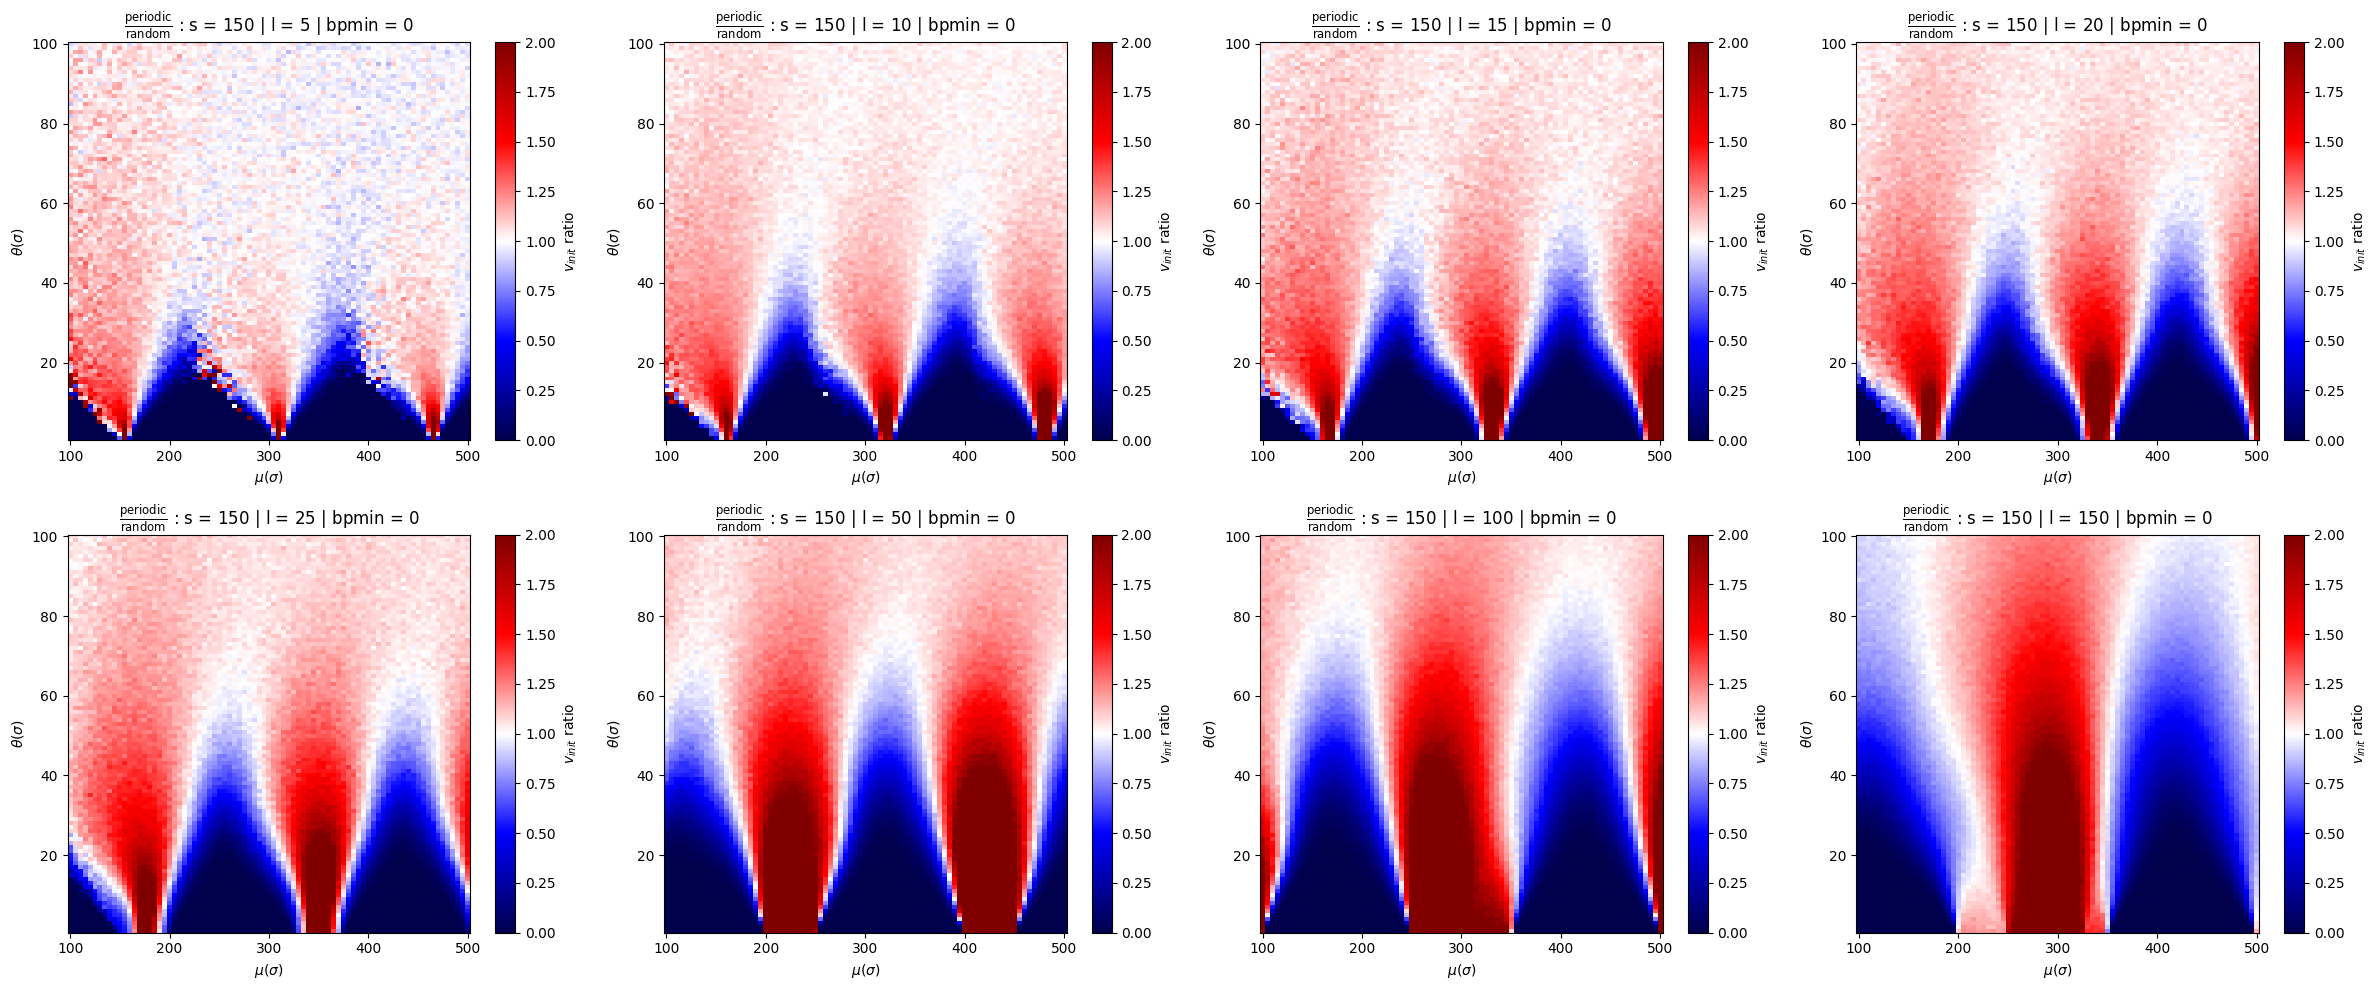

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from nucleo.io.plots_2D import (
    find_config_idx,
    plot_one_heatmap_ratio_from_df,
)

df = pl.read_parquet(root + "ncl_heatmaps.parquet")

S = 150
BPMIN = 0
LAND_NUM = "periodic"
LAND_DEN = "random"

nrows, ncols = 2, 4

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 5 * nrows),
    squeeze=False,
)

for ax, l in zip(axes.ravel(), ls):

    idx_num = find_config_idx(
        df,
        s=S,
        l=l,
        bpmin=BPMIN,
        land=LAND_NUM,
    )

    idx_den = find_config_idx(
        df,
        s=S,
        l=l,
        bpmin=BPMIN,
        land=LAND_DEN,
    )

    plot_one_heatmap_ratio_from_df(
        df,
        config_idx_num=idx_num,
        config_idx_den=idx_den,
        speed_col="vf",
        ax=ax,
        cmap="seismic",
    )

# Cacher les axes en trop si len(ls) < 8
for ax in axes.ravel()[len(ls):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("supfig2_final.png", bbox_inches="tight")

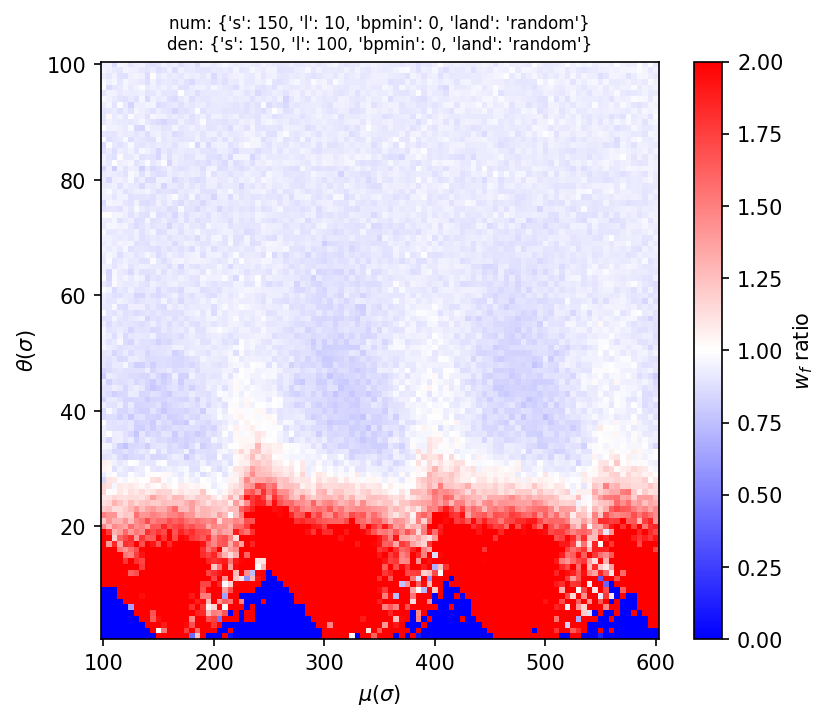

In [17]:
import polars as pl
from pathlib import Path
from nucleo.io.plots_2D import find_config_idx, plot_one_heatmap_ratio_from_df


root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/")
df = pl.read_parquet(root / "ncl_heatmaps.parquet")

s = 150
l = 10
bpmin = 0
land = "random"

idx_num = find_config_idx(df, s=s, l=10, bpmin=bpmin, land=land)
idx_den = find_config_idx(df, s=s, l=100, bpmin=bpmin, land=land)

ax, c = plot_one_heatmap_ratio_from_df(
    df,
    config_idx_num=idx_num,
    config_idx_den=idx_den,
    speed_col="wf",
    value_col="value_raw",
)

# .